In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [149]:
data = pd.read_csv('churn.csv')

In [150]:
df = data.copy()

In [151]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


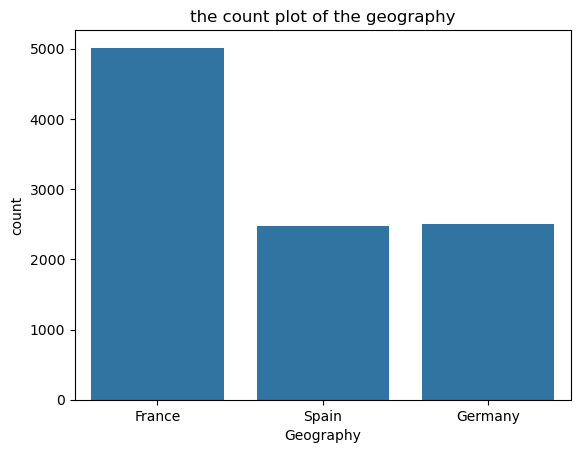

In [152]:
plt.Figure(figsize=(8,6))
sns.countplot(data=df,x='Geography')
plt.title('the count plot of the geography')
plt.show()

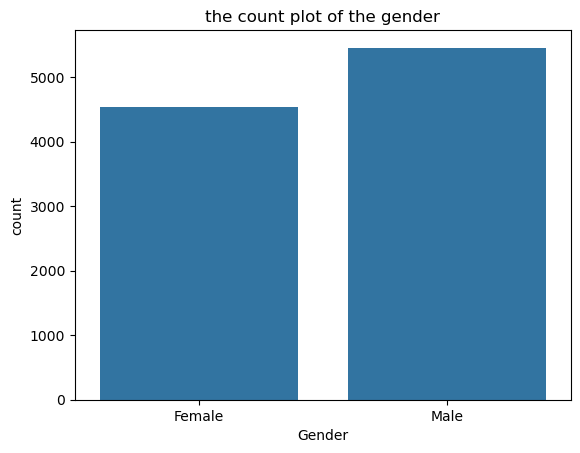

In [153]:
plt.Figure(figsize=(8,6))
sns.countplot(data=df,x='Gender')
plt.title('the count plot of the gender')
plt.show()

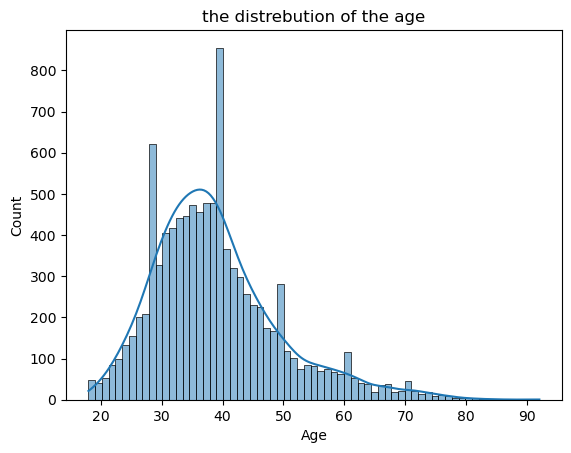

In [154]:
plt.Figure(figsize=(8,6))
sns.histplot(data=df,x='Age',kde=True)
plt.title('the distrebution of the age')
plt.show()

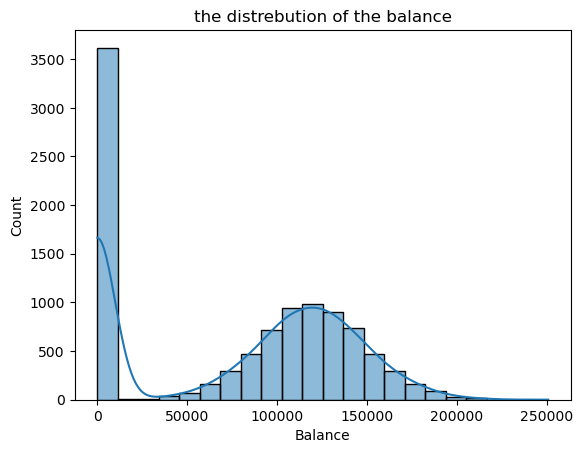

In [155]:
plt.Figure(figsize=(8,6))
sns.histplot(data=df,x='Balance',kde=True)
plt.title('the distrebution of the balance')
plt.show()

In [156]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [157]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [158]:
from sklearn.preprocessing import StandardScaler

In [159]:
scaler = StandardScaler()

In [160]:
numeric_cols = ['CreditScore','Age','Tenure','Balance','EstimatedSalary']

In [161]:
df[numeric_cols]=scaler.fit_transform(df[numeric_cols])

In [162]:
df = df.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [163]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,-0.326221,France,Female,0.293517,-1.041760,-1.225848,1,1,1,0.021886,1
1,-0.440036,Spain,Female,0.198164,-1.387538,0.117350,1,0,1,0.216534,0
2,-1.536794,France,Female,0.293517,1.032908,1.333053,3,1,0,0.240687,1
3,0.501521,France,Female,0.007457,-1.387538,-1.225848,2,0,0,-0.108918,0
4,2.063884,Spain,Female,0.388871,-1.041760,0.785728,1,1,1,-0.365276,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,1.246488,France,Male,0.007457,-0.004426,-1.225848,2,1,0,-0.066419,0
9996,-1.391939,France,Male,-0.373958,1.724464,-0.306379,1,1,1,0.027988,0
9997,0.604988,France,Female,-0.278604,0.687130,-1.225848,1,0,1,-1.008643,1
9998,1.256835,Germany,Male,0.293517,-0.695982,-0.022608,2,1,0,-0.125231,1


In [164]:
from sklearn.preprocessing import LabelEncoder

In [165]:
from sklearn.preprocessing import LabelEncoder

cols = ['Geography', 'Gender']
encoders = {}

for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [166]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,-0.326221,0,0,0.293517,-1.041760,-1.225848,1,1,1,0.021886,1
1,-0.440036,2,0,0.198164,-1.387538,0.117350,1,0,1,0.216534,0
2,-1.536794,0,0,0.293517,1.032908,1.333053,3,1,0,0.240687,1
3,0.501521,0,0,0.007457,-1.387538,-1.225848,2,0,0,-0.108918,0
4,2.063884,2,0,0.388871,-1.041760,0.785728,1,1,1,-0.365276,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,1.246488,0,1,0.007457,-0.004426,-1.225848,2,1,0,-0.066419,0
9996,-1.391939,0,1,-0.373958,1.724464,-0.306379,1,1,1,0.027988,0
9997,0.604988,0,0,-0.278604,0.687130,-1.225848,1,0,1,-1.008643,1
9998,1.256835,1,1,0.293517,-0.695982,-0.022608,2,1,0,-0.125231,1


In [167]:
x = df.drop(['Exited'],axis=1)
y= df[['Exited']]

In [168]:
from sklearn.model_selection import train_test_split

In [169]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42,shuffle=True)

In [170]:
from sklearn.neighbors import KNeighborsClassifier

In [171]:
classifier = KNeighborsClassifier(n_neighbors=7)

In [172]:
classifier.fit(x_train,y_train)

c:\Users\seifa\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



KNeighborsClassifier(n_neighbors=7)

In [173]:
y_pred = classifier.predict(x_test)

In [174]:
from sklearn.metrics import f1_score,classification_report,accuracy_score,confusion_matrix

In [175]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1793
           1       0.37      0.70      0.48       207

    accuracy                           0.84      2000
   macro avg       0.67      0.78      0.70      2000
weighted avg       0.90      0.84      0.86      2000



In [176]:
test_error_rates = []

for k in range(1,10):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(x_train,y_train) 
   
    y_pred_test = knn_model.predict(x_test)
    
    test_error = 1 - accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)

c:\Users\seifa\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

c:\Users\seifa\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

c:\Users\seifa\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

c:\Users\seifa\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

c:\Users\seifa\anaconda3\Lib\sit

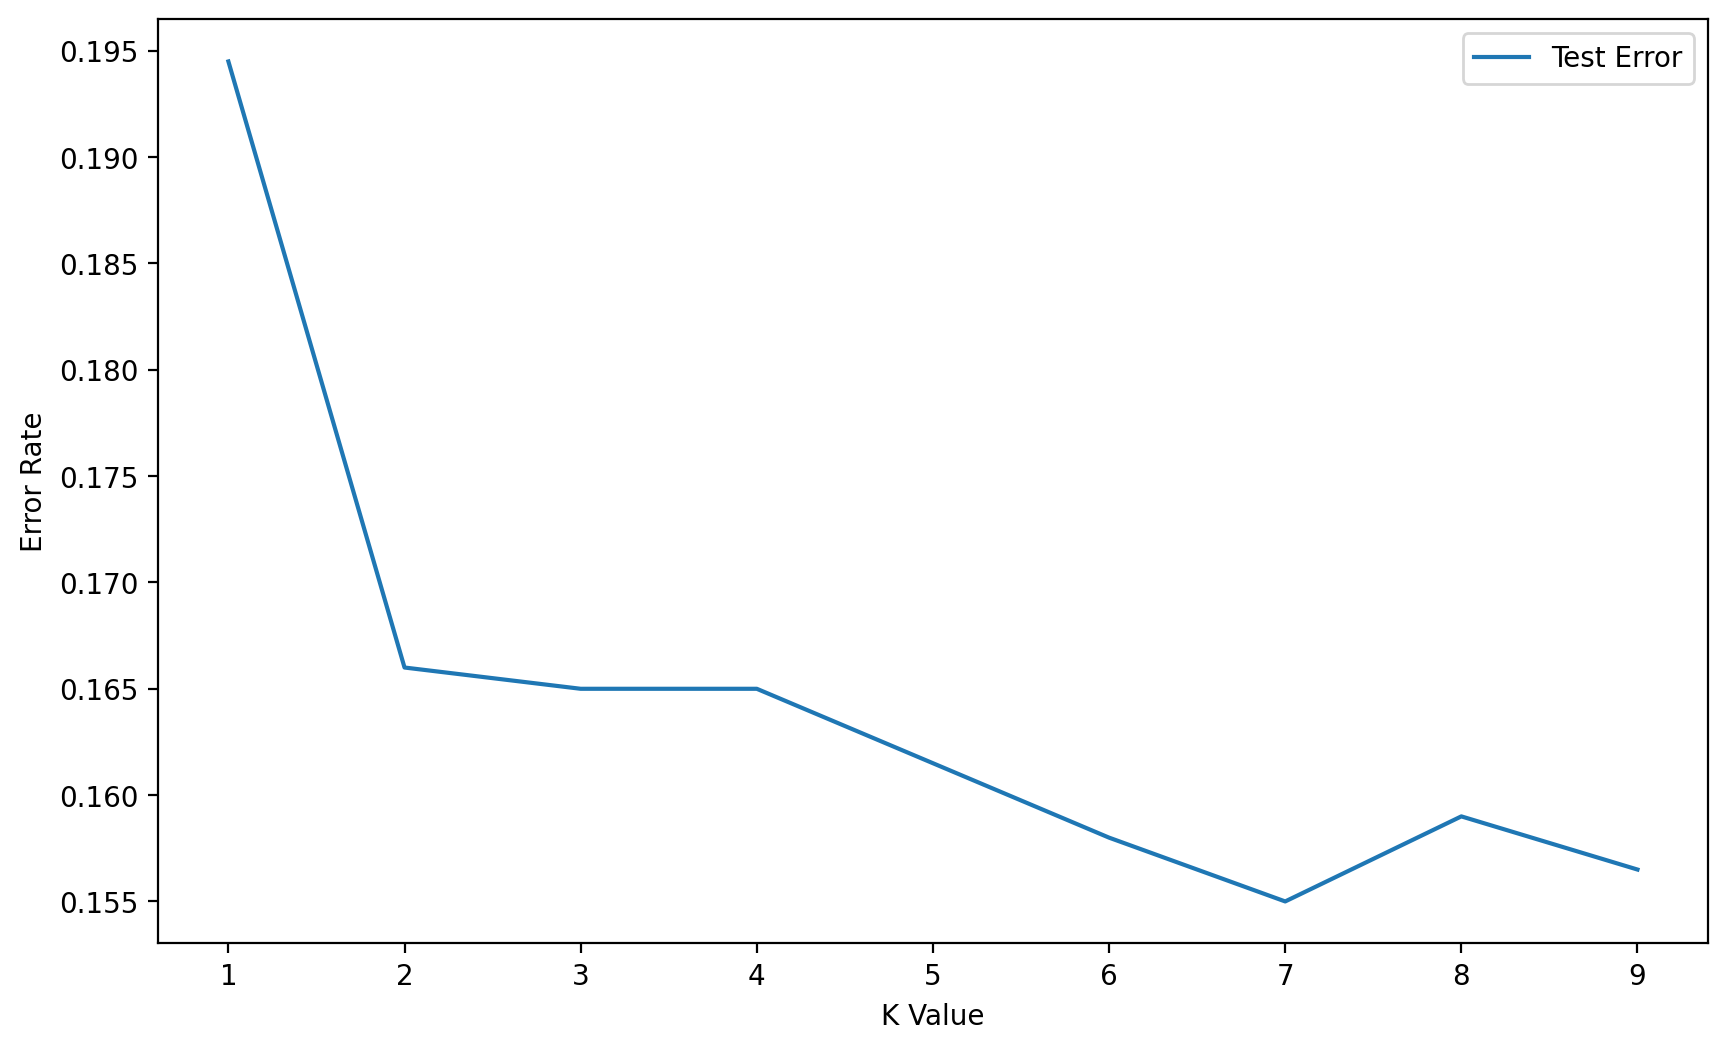

In [177]:
plt.figure(figsize=(10,6),dpi=200)
plt.plot(range(1,10),test_error_rates,label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")
plt.show()

In [178]:
from sklearn.svm import SVC

In [179]:
calssifier = SVC(kernel='poly',random_state=42,C=0.6,degree=5)

In [180]:
calssifier.fit(x_train,y_train)

c:\Users\seifa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



SVC(C=0.6, degree=5, kernel='poly', random_state=42)

In [181]:
y_pred = classifier.predict(x_test)

In [182]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1793
           1       0.37      0.70      0.48       207

    accuracy                           0.84      2000
   macro avg       0.67      0.78      0.70      2000
weighted avg       0.90      0.84      0.86      2000



In [183]:
from sklearn.tree import DecisionTreeClassifier

In [184]:
classifier = DecisionTreeClassifier(criterion='entropy',max_depth=8,random_state=42)

In [185]:
classifier.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=42)

In [186]:
y_pred = classifier.predict(x_test)

In [187]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      1785
           1       0.39      0.71      0.50       215

    accuracy                           0.85      2000
   macro avg       0.68      0.79      0.71      2000
weighted avg       0.90      0.85      0.87      2000



In [188]:
from sklearn.ensemble import RandomForestClassifier

In [189]:
classifier = RandomForestClassifier(criterion='entropy',max_depth=8,random_state=42,n_estimators=10)

In [191]:
classifier.fit(x_train,y_train)

c:\Users\seifa\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



RandomForestClassifier(criterion='entropy', max_depth=8, n_estimators=10,
                       random_state=42)

In [192]:
y_pred = classifier.predict(x_test)

In [193]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.98      0.87      0.92      1810
           1       0.38      0.79      0.52       190

    accuracy                           0.86      2000
   macro avg       0.68      0.83      0.72      2000
weighted avg       0.92      0.86      0.88      2000

